In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

## DIAGNÓSTICO DATA SET (SHAPE, INFO, HEAD)

In [4]:
import pandas as pd

def resumen_dataset(df, nombre_dataset="Dataset"):
    print(f"Resumen del {nombre_dataset}:\n")
    print(f"Dimensiones: {df.shape}")
    print("\nTipos de datos:")
    print("\nDtypes e información general:")
    print(df.info())
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("\nPrimeras 5 filas:")
    print(df.head())

In [5]:
resumen_dataset(X, nombre_dataset="Features (X)")

Resumen del Features (X):

Dimensiones: (45211, 16)

Tipos de datos:

Dtypes e información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB
Non

In [6]:
resumen_dataset(y, nombre_dataset="Target (y)")

Resumen del Target (y):

Dimensiones: (45211, 1)

Tipos de datos:

Dtypes e información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   y       45211 non-null  object
dtypes: object(1)
memory usage: 353.3+ KB
None

Valores nulos por columna:
y    0
dtype: int64

Primeras 5 filas:
    y
0  no
1  no
2  no
3  no
4  no


## Nos quedamos con variables númericas y empezamos con el KNN


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [8]:
features_num = X.select_dtypes(include=['int64', 'float64']).copy()

X_model = features_num
y_model = y

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.20, random_state=42)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

In [10]:
knn.fit(X_train, y_train.values.ravel())

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
score = knn.score(X_test, y_test)
print(f"Accuracy del modelo KNN: {score:.4f}")

Accuracy del modelo KNN: 0.8754


## Limpiamos datos 

In [12]:
import numpy as np         


### matriz de heatmap de correlación para ver la relevancia de las variables numéricas

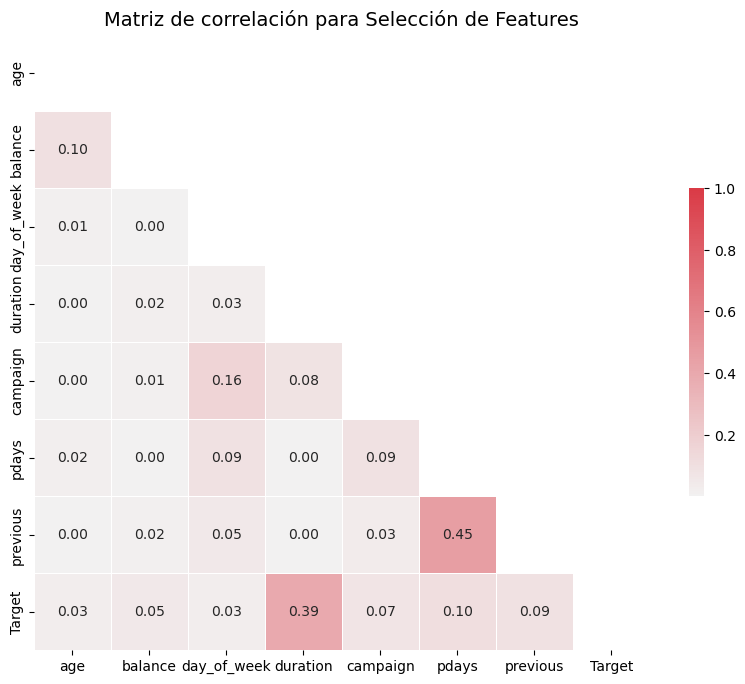

In [13]:
df_heatmap = features_num.copy()
df_heatmap['Target'] = y['y'].apply(lambda x: 1 if x == 'yes' else 0)

correlation_matrix =np.abs(df_heatmap.corr())

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(correlation_matrix, mask=mask, cmap=cmap, vmax=1, center=0, square=True, 
            linewidths=.5, cbar_kws={"shrink": .5}, annot=True, fmt=".2f")

plt.title("Matriz de correlación para Selección de Features", fontsize=14)
plt.show()


## Quitamos las variables que tienen menos relación

In [14]:
X_train_reduced = X_train.drop(columns=["campaign", "balance", "age", "day_of_week"])
X_test_reduced = X_test.drop(columns=["campaign", "balance", "age", "day_of_week"])

In [15]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_reduced, y_train.values.ravel())

knn.score(X_test_reduced, y_test)

0.8852150834899922

In [16]:
columnas_texto = X.select_dtypes(include=['object']).columns

X_encoded = pd.get_dummies(X, columns=columnas_texto, drop_first=True, dtype=int)

print(X.shape)
print(X_encoded.shape)

(45211, 16)
(45211, 38)


## Dividimos de nuevo el data set para train y test

In [17]:
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42)

In [18]:
knn_enc = KNeighborsClassifier(n_neighbors=10)
knn_enc.fit(X_train_enc, y_train_enc.values.ravel())

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
knn_enc.score(X_test_enc, y_test_enc)

0.8805706070994139

C:\Users\llam_\AppData\Local\Temp\ipykernel_113844\4031201052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y['y'], palette='pastel')


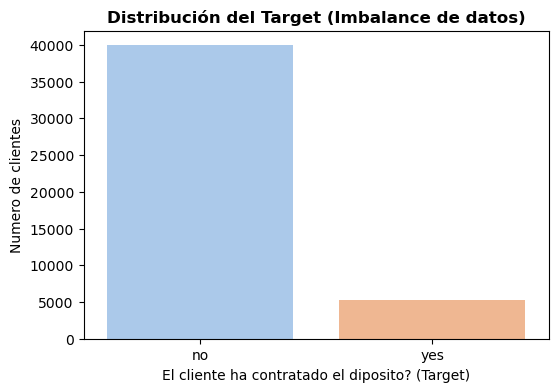

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y['y'], palette='pastel')
plt.title('Distribución del Target (Imbalance de datos)', fontsize=12, fontweight='bold')
plt.xlabel('El cliente ha contratado el diposito? (Target)', fontsize=10)
plt.ylabel('Numero de clientes', fontsize=10)

plt.show()

## Empezamos con el escalado 

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
normalizer = MinMaxScaler()
normalizer.fit(X_train_enc)

X_train_norm = pd.DataFrame(normalizer.transform(X_train_enc), columns=X_train_enc.columns)
X_test_norm = pd.DataFrame(normalizer.transform(X_test_enc), columns=X_test_enc.columns)

X_train_final = X_train_norm.drop(columns=["campaign", "balance", "age", "day_of_week"])
X_test_final = X_test_norm.drop(columns=["campaign", "balance", "age", "day_of_week"])

## aplicamos regresión logística

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train_enc.values.ravel())

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(X_test_final)

In [26]:
print("METRICAS DE RENDIMIENTO:")
print("Accuracy: ", accuracy_score(y_test_enc, y_pred))
print("Precision:", precision_score(y_test_enc, y_pred, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, y_pred, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, y_pred, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, y_pred))

METRICAS DE RENDIMIENTO:
Accuracy:  0.8980426849496849
Precision: 0.6597353497164461
Recall:    0.3198900091659028
F1-Score:  0.4308641975308642

MATRIZ DE CONFUSIÓN:
[[7772  180]
 [ 742  349]]


In [27]:
coef = pd.Series(model.coef_[0], index=X_train_final.columns).sort_values(key=np.abs, ascending=False)
print("\nCOEFICIENTES (ordenados por impacto absoluto):\n", coef)

print("\nIntercept:", model.intercept_[0])


COEFICIENTES (ordenados por impacto absoluto):
 duration               18.118798
poutcome_success        2.429080
month_mar               1.350017
month_jan              -1.195614
month_may              -1.086095
pdays                   0.974593
month_jul              -0.889527
month_nov              -0.845243
month_aug              -0.839237
month_jun              -0.763146
housing_yes            -0.747733
month_oct               0.707103
month_sep               0.623590
job_student             0.429775
month_feb              -0.421633
loan_yes               -0.421252
job_housemaid          -0.413335
education_tertiary      0.378137
month_dec               0.369844
poutcome_other          0.356219
job_entrepreneur       -0.326449
job_blue-collar        -0.314950
job_retired             0.296776
job_self-employed      -0.216612
marital_married        -0.180608
previous                0.179444
job_services           -0.177860
education_secondary     0.176701
job_technician         -0.1

## aplicamos oversampling para balancear la muestra y volvemos a aplicar la regresión logística

In [28]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [29]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train_enc)

print("Target original al Train:", Counter(y_train_enc['y']))
print("Target balanceado con SMOTE al Train:", Counter(y_train_resampled['y']))

Target original al Train: Counter({'no': 31970, 'yes': 4198})
Target balanceado con SMOTE al Train: Counter({'no': 31970, 'yes': 31970})


In [30]:
model_bal = LogisticRegression(max_iter=1000)
model_bal.fit(X_train_resampled, y_train_resampled.values.ravel())

y_pred = model_bal.predict(X_test_final)

In [31]:
print("METRICAS DE RENDIMIENTO:")
print("Accuracy: ", accuracy_score(y_test_enc, y_pred))
print("Precision:", precision_score(y_test_enc, y_pred, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, y_pred, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, y_pred, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, y_pred))

METRICAS DE RENDIMIENTO:
Accuracy:  0.83932323344023
Precision: 0.4134799235181644
Recall:    0.7928505957836847
F1-Score:  0.5435124096764059

MATRIZ DE CONFUSIÓN:
[[6725 1227]
 [ 226  865]]


## Aplicamos arbol de decisiones

In [32]:
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [33]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)


In [34]:
tree.fit(X_train_resampled, y_train_resampled.values.ravel())

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
pred = tree.predict(X_test_final)

In [36]:
print("METRICAS ARBOL DE DECISIONES (CLASSIFICACIÓN):")
print("Accuracy: ", accuracy_score(y_test_enc, pred))
print("Precision:", precision_score(y_test_enc, pred, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred))

METRICAS ARBOL DE DECISIONES (CLASSIFICACIÓN):
Accuracy:  0.778723874820303
Precision: 0.32894736842105265
Recall:    0.8020164986251146
F1-Score:  0.46654225539856037

MATRIZ DE CONFUSIÓN:
[[6167 1785]
 [ 216  875]]


In [37]:
tree_importance = {feature : importance for feature, importance in zip(X_train_final.columns, tree.feature_importances_)}

In [38]:
tree_importance_sorted = pd.Series(tree_importance).sort_values(ascending=False)
print("\nIMPORTANCIA DE LAS VARIABLES:\n", tree_importance_sorted[tree_importance_sorted > 0])


IMPORTANCIA DE LAS VARIABLES:
 duration            0.717114
housing_yes         0.135859
poutcome_success    0.104818
month_mar           0.042209
dtype: float64


In [39]:
print("\nESTRUCTURA LÓGICA DE L'ARBRE (TEXT):")
tree_viz = export_text(tree, feature_names=list(X_train_final.columns))
print(tree_viz)


ESTRUCTURA LÓGICA DE L'ARBRE (TEXT):
|--- duration <= 0.04
|   |--- poutcome_success <= 0.00
|   |   |--- month_mar <= 0.00
|   |   |   |--- class: no
|   |   |--- month_mar >  0.00
|   |   |   |--- class: yes
|   |--- poutcome_success >  0.00
|   |   |--- duration <= 0.03
|   |   |   |--- class: yes
|   |   |--- duration >  0.03
|   |   |   |--- class: yes
|--- duration >  0.04
|   |--- duration <= 0.09
|   |   |--- housing_yes <= 1.00
|   |   |   |--- class: yes
|   |   |--- housing_yes >  1.00
|   |   |   |--- class: no
|   |--- duration >  0.09
|   |   |--- duration <= 0.13
|   |   |   |--- class: yes
|   |   |--- duration >  0.13
|   |   |   |--- class: yes



## tabla para ver la comparación de los resultados entre regresión logística y árbol de decisiones

In [40]:
datos_comparativa = {
    "Metrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Regressión Logística (SMOTE)": [0.8393, 0.4135, 0.7929, 0.5435],
    "Arbol de Decisión (SMOTE)": [0.7787, 0.3289, 0.8020, 0.4665]
}
df_comparativa = pd.DataFrame(datos_comparativa)
df_comparativa.set_index("Metrica", inplace=True)
df_comparativa

,Regressión Logística (SMOTE),Arbol de Decisión (SMOTE)
Metrica,,
Accuracy,0.8393,0.7787
Precision,0.4135,0.3289
Recall,0.7929,0.8020
F1-Score,0.5435,0.4665


## APLICAMOS BAGGING

In [41]:
from sklearn.ensemble import BaggingClassifier

In [43]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=20, random_state=42), 
    n_estimators=100,      
    max_samples=1000,      
    random_state=42)

In [44]:
bagging_clf.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1000
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [46]:
pred_bag = bagging_clf.predict(X_test_final)

In [47]:
print("METRICAS BAGGING CLASSIFIER:")
print("Accuracy: ", accuracy_score(y_test_enc, pred_bag))
print("Precision:", precision_score(y_test_enc, pred_bag, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_bag, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_bag, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_bag))

METRICAS BAGGING CLASSIFIER:
Accuracy:  0.8252792214972907
Precision: 0.3931847968545216
Recall:    0.8249312557286893
F1-Score:  0.5325443786982249

MATRIZ DE CONFUSIÓN:
[[6563 1389]
 [ 191  900]]


## APLICAMOS RANDOM FOREST

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
forest_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

In [50]:
forest_clf.fit(X_train_resampled, y_train_resampled.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
pred_forest = forest_clf.predict(X_test_final)

In [53]:
print("MÉTRICAS RANDOM FOREST (CLASIFICACIÓN):")
print("Accuracy: ", accuracy_score(y_test_enc, pred_forest))
print("Precision:", precision_score(y_test_enc, pred_forest, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_forest, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_forest, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_forest))

MÉTRICAS RANDOM FOREST (CLASIFICACIÓN):
Accuracy:  0.8532566626119651
Precision: 0.4353778751369113
Recall:    0.7286892758936755
F1-Score:  0.5450805622214604

MATRIZ DE CONFUSIÓN:
[[6921 1031]
 [ 296  795]]


## APLICAMOS GRADIENT BOOSTER

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

In [55]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,      
    random_state=42)

In [56]:
gb_clf.fit(X_train_resampled, y_train_resampled.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [57]:
pred_gb = gb_clf.predict(X_test_final)

In [59]:
print("MÉTRICAS GRADIENT BOOSTING (CLASIFICACIÓN):")
print("Accuracy: ", accuracy_score(y_test_enc, pred_gb))
print("Precision:", precision_score(y_test_enc, pred_gb, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_gb, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_gb, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_gb))

MÉTRICAS GRADIENT BOOSTING (CLASIFICACIÓN):
Accuracy:  0.8335729293376092
Precision: 0.4049586776859504
Recall:    0.8084326306141155
F1-Score:  0.5396145610278372

MATRIZ DE CONFUSIÓN:
[[6656 1296]
 [ 209  882]]


## APLICAMOS ADA BOOST

In [60]:
from sklearn.ensemble import AdaBoostClassifier

In [61]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)

In [62]:
ada_clf.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [63]:
pred_ada = ada_clf.predict(X_test_final)

In [65]:
print("MÉTRICAS ADABOOST (CLASIFICACIÓN):")
print("Accuracy: ", accuracy_score(y_test_enc, pred_ada))
print("Precision:", precision_score(y_test_enc, pred_ada, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_ada, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_ada, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_ada))

MÉTRICAS ADABOOST (CLASIFICACIÓN):
Accuracy:  0.8189760035386486
Precision: 0.3814074717636838
Recall:    0.8047662694775435
F1-Score:  0.5175361037430003

MATRIZ DE CONFUSIÓN:
[[6528 1424]
 [ 213  878]]


## tabla comparativa de los resultados

In [66]:
datos_totales = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Regr. Logística": [0.8393, 0.4135, 0.7929, 0.5435],
    "Árbol Decisión": [0.7787, 0.3289, 0.8020, 0.4665],
    "Bagging": [0.8253, 0.3932, 0.8249, 0.5325],
    "Random Forest": [0.8533, 0.4354, 0.7287, 0.5451],
    "Gradient Boosting": [0.8336, 0.4050, 0.8084, 0.5396],
    "AdaBoost": [0.8190, 0.3814, 0.8048, 0.5175]
}

df_total = pd.DataFrame(datos_totales)
df_total.set_index("Métrica", inplace=True)

df_total.round(4)

,Regr. Logística,Árbol Decisión,Bagging,Random Forest,Gradient Boosting,AdaBoost
Métrica,,,,,,
Accuracy,0.8393,0.7787,0.8253,0.8533,0.8336,0.8190
Precision,0.4135,0.3289,0.3932,0.4354,0.4050,0.3814
Recall,0.7929,0.8020,0.8249,0.7287,0.8084,0.8048
F1-Score,0.5435,0.4665,0.5325,0.5451,0.5396,0.5175


## Aplicamos Grid a los dos mejores modelos (random forest y bagging)

## Grid con random forest

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer

In [75]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_leaf_nodes": [250, 500, None],
    "max_depth": [10, 30, 50]
}

In [76]:
f1_scorer = make_scorer(f1_score, pos_label='yes')

In [77]:
rf_base = RandomForestClassifier(random_state=42)

In [78]:
grid_search_rf = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring=f1_scorer, 
    n_jobs=-1)

In [79]:
grid_search_rf.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 30, ...], 'max_leaf_nodes': [250, 500, ...], 'n_estimators': [50, 100, ...]}"
,scoring,make_scorer(f...pos_label=yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [80]:
print("MEJORES PARÁMETROS RANDOM FOREST:", grid_search_rf.best_params_)
best_rf_model = grid_search_rf.best_estimator_

MEJORES PARÁMETROS RANDOM FOREST: {'max_depth': 30, 'max_leaf_nodes': None, 'n_estimators': 200}


In [81]:
pred_rf_grid = best_rf_model.predict(X_test_final)

In [84]:
print("\nMÉTRICAS RANDOM FOREST OPTIMIZADO:")
print("Accuracy: ", accuracy_score(y_test_enc, pred_rf_grid))
print("Precision:", precision_score(y_test_enc, pred_rf_grid, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_rf_grid, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_rf_grid, pos_label='yes'))


MÉTRICAS RANDOM FOREST OPTIMIZADO:
Accuracy:  0.8591175494857901
Precision: 0.4420519316022799
Recall:    0.6397800183318056
F1-Score:  0.5228464419475656


In [85]:
print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_rf_grid))


MATRIZ DE CONFUSIÓN:
[[7071  881]
 [ 393  698]]


## Grid con bagging 

In [86]:
param_grid_bag = {
    "n_estimators": [50, 100, 200],
    "estimator__max_leaf_nodes": [250, 500, None],
    "estimator__max_depth": [10, 30, 50]
}

In [87]:
bag_base = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

In [88]:
f1_scorer = make_scorer(f1_score, pos_label='yes')

In [90]:
grid_search_bag = GridSearchCV(
    estimator=bag_base, 
    param_grid=param_grid_bag, 
    cv=5, 
    scoring=f1_scorer,
    n_jobs=-1
)

In [91]:
grid_search_bag.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,BaggingClassi...ndom_state=42)
,param_grid,"{'estimator__max_depth': [10, 30, ...], 'estimator__max_leaf_nodes': [250, 500, ...], 'n_estimators': [50, 100, ...]}"
,scoring,make_scorer(f...pos_label=yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [92]:
print("MEJORES PARÁMETROS BAGGING:", grid_search_bag.best_params_)
best_bag_model = grid_search_bag.best_estimator_

MEJORES PARÁMETROS BAGGING: {'estimator__max_depth': 30, 'estimator__max_leaf_nodes': None, 'n_estimators': 200}


In [93]:
pred_bag_grid = best_bag_model.predict(X_test_final)

In [94]:
print("\nMÉTRICAS BAGGING OPTIMIZADO:")
print("Accuracy: ", accuracy_score(y_test_enc, pred_bag_grid))
print("Precision:", precision_score(y_test_enc, pred_bag_grid, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_bag_grid, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_bag_grid, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_bag_grid))


MÉTRICAS BAGGING OPTIMIZADO:
Accuracy:  0.8479486895941613
Precision: 0.4202247191011236
Recall:    0.6856095325389551
F1-Score:  0.5210727969348659

MATRIZ DE CONFUSIÓN:
[[6920 1032]
 [ 343  748]]


## tabla de resultados generales con  grid incluido

In [95]:
datos_proyecto_ml = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Regr. Logística (SMOTE)": [0.8393, 0.4135, 0.7929, 0.5435],
    "Árbol Decisión (SMOTE)": [0.7787, 0.3289, 0.8020, 0.4665],
    "Bagging Base": [0.8253, 0.3932, 0.8249, 0.5325],
    "Bagging Optimizado (Grid)": [0.8479, 0.4202, 0.6856, 0.5211],
    "Random Forest Base": [0.8533, 0.4354, 0.7287, 0.5451],
    "Random Forest Optimizado (Grid)": [0.8591, 0.4421, 0.6398, 0.5228],
    "Gradient Boosting": [0.8336, 0.4050, 0.8084, 0.5396],
    "AdaBoost": [0.8190, 0.3814, 0.8048, 0.5175]}

df_proyecto_ml = pd.DataFrame(datos_proyecto_ml)
df_proyecto_ml.set_index("Métrica", inplace=True)
df_proyecto_ml.round(4)

,Regr. Logística (SMOTE),Árbol Decisión (SMOTE),Bagging Base,Bagging Optimizado (Grid),Random Forest Base,Random Forest Optimizado (Grid),Gradient Boosting,AdaBoost
Métrica,,,,,,,,
Accuracy,0.8393,0.7787,0.8253,0.8479,0.8533,0.8591,0.8336,0.8190
Precision,0.4135,0.3289,0.3932,0.4202,0.4354,0.4421,0.4050,0.3814
Recall,0.7929,0.8020,0.8249,0.6856,0.7287,0.6398,0.8084,0.8048
F1-Score,0.5435,0.4665,0.5325,0.5211,0.5451,0.5228,0.5396,0.5175


## Aplicamos random search para random forest y bagging

## random forest

In [96]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [97]:
random_grid_rf = {
    "n_estimators": [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    "max_leaf_nodes": [int(x) for x in np.linspace(start=500, stop=3000, num=10)] + [None],
    "max_depth": [int(x) for x in np.linspace(10, 110, num=11)] + [None]
}

In [98]:
rf_base = RandomForestClassifier(random_state=42)

In [99]:
f1_scorer = make_scorer(f1_score, pos_label='yes')

In [100]:
random_search_rf = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=random_grid_rf, 
    n_iter=10, 
    cv=5, 
    scoring=f1_scorer,
    n_jobs=-1,
    random_state=42
)

In [101]:
random_search_rf.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_leaf_nodes': [500, 777, ...], 'n_estimators': [200, 400, ...]}"
,n_iter,10
,scoring,make_scorer(f...pos_label=yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [102]:
print("MEJORES PARÁMETROS RF (RANDOM SEARCH):", random_search_rf.best_params_)
best_rf_random = random_search_rf.best_estimator_

MEJORES PARÁMETROS RF (RANDOM SEARCH): {'n_estimators': 200, 'max_leaf_nodes': 3000, 'max_depth': 80}


In [103]:
pred_rf_random = best_rf_random.predict(X_test_final)

In [104]:
print("\nMÉTRICAS RANDOM FOREST (RANDOM SEARCH):")
print("Accuracy: ", accuracy_score(y_test_enc, pred_rf_random))
print("Precision:", precision_score(y_test_enc, pred_rf_random, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_rf_random, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_rf_random, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_rf_random))


MÉTRICAS RANDOM FOREST (RANDOM SEARCH):
Accuracy:  0.8603339599690368
Precision: 0.4514124293785311
Recall:    0.7323556370302475
F1-Score:  0.5585459629500175

MATRIZ DE CONFUSIÓN:
[[6981  971]
 [ 292  799]]


## Bagging

In [105]:
random_grid_bag = {
    "n_estimators": [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    "estimator__max_leaf_nodes": [int(x) for x in np.linspace(start=500, stop=3000, num=10)] + [None],
    "estimator__max_depth": [int(x) for x in np.linspace(10, 110, num=11)] + [None]
}

In [106]:
bag_base = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42)

In [107]:
f1_scorer = make_scorer(f1_score, pos_label='yes')

In [108]:
random_search_bag = RandomizedSearchCV(
    estimator=bag_base, 
    param_distributions=random_grid_bag, 
    n_iter=10, 
    cv=5, 
    scoring=f1_scorer,
    n_jobs=-1,
    random_state=42
)

In [109]:
random_search_bag.fit(X_train_resampled, y_train_resampled.values.ravel())

,estimator,BaggingClassi...ndom_state=42)
,param_distributions,"{'estimator__max_depth': [10, 20, ...], 'estimator__max_leaf_nodes': [500, 777, ...], 'n_estimators': [200, 400, ...]}"
,n_iter,10
,scoring,make_scorer(f...pos_label=yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [110]:
print("MEJORES PARÁMETROS BAGGING (RANDOM SEARCH):", random_search_bag.best_params_)
best_bag_random = random_search_bag.best_estimator_

MEJORES PARÁMETROS BAGGING (RANDOM SEARCH): {'n_estimators': 1000, 'estimator__max_leaf_nodes': 1888, 'estimator__max_depth': 100}


In [111]:
pred_bag_random = best_bag_random.predict(X_test_final)

In [112]:
print("\nMÉTRICAS BAGGING (RANDOM SEARCH):")
print("Accuracy: ", accuracy_score(y_test_enc, pred_bag_random))
print("Precision:", precision_score(y_test_enc, pred_bag_random, pos_label='yes'))
print("Recall:   ", recall_score(y_test_enc, pred_bag_random, pos_label='yes'))
print("F1-Score: ", f1_score(y_test_enc, pred_bag_random, pos_label='yes'))

print("\nMATRIZ DE CONFUSIÓN:")
print(confusion_matrix(y_test_enc, pred_bag_random))


MÉTRICAS BAGGING (RANDOM SEARCH):
Accuracy:  0.8503815105606547
Precision: 0.430614406779661
Recall:    0.7451879010082493
F1-Score:  0.5458207452165156

MATRIZ DE CONFUSIÓN:
[[6877 1075]
 [ 278  813]]


In [114]:
datos_finalisimos = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Regr. Logística (SMOTE)": [0.8393, 0.4135, 0.7929, 0.5435],
    "Árbol Decisión (SMOTE)": [0.7787, 0.3289, 0.8020, 0.4665],
    "Bagging Base": [0.8253, 0.3932, 0.8249, 0.5325],
    "Bagging Grid Search": [0.8479, 0.4202, 0.6856, 0.5211],
    "Bagging Random Search": [0.8504, 0.4306, 0.7452, 0.5458],
    "Random Forest Base": [0.8533, 0.4354, 0.7287, 0.5451],
    "Random Forest Grid Search": [0.8591, 0.4421, 0.6398, 0.5228],
    "Random Forest Random Search": [0.8603, 0.4514, 0.7324, 0.5585],
    "Gradient Boosting": [0.8336, 0.4050, 0.8084, 0.5396],
    "AdaBoost": [0.8190, 0.3814, 0.8048, 0.5175]
}

df_finalisimo = pd.DataFrame(datos_finalisimos)
df_finalisimo.set_index("Métrica", inplace=True)
df_finalisimo.round(4)

,Regr. Logística (SMOTE),Árbol Decisión (SMOTE),Bagging Base,Bagging Grid Search,Bagging Random Search,Random Forest Base,Random Forest Grid Search,Random Forest Random Search,Gradient Boosting,AdaBoost
Métrica,,,,,,,,,,
Accuracy,0.8393,0.7787,0.8253,0.8479,0.8504,0.8533,0.8591,0.8603,0.8336,0.8190
Precision,0.4135,0.3289,0.3932,0.4202,0.4306,0.4354,0.4421,0.4514,0.4050,0.3814
Recall,0.7929,0.8020,0.8249,0.6856,0.7452,0.7287,0.6398,0.7324,0.8084,0.8048
F1-Score,0.5435,0.4665,0.5325,0.5211,0.5458,0.5451,0.5228,0.5585,0.5396,0.5175
